# 04v2 — Exploration Audio : MM-USED-Fallacy

Ce notebook explore les propriétés acoustiques du sous-ensemble audio du dataset MM-USED-Fallacy (5 dialogues avec clips alignés sur 35, soit ~38 % du corpus). Il analyse la distribution des durées, l'alignement temporel des clips, la longueur des snippets et les waveforms/spectrogrammes par classe. La logique est dans `src/data/audio_edea.py`.

## Sommaire

- [§1 Distribution des classes (sous-ensemble audio)](#1-distribution-des-classes)
- [§2 Durée des clips audio](#2-durée-des-clips-audio)
- [§3 Clips par dialogue](#3-clips-par-dialogue)
- [§4 Longueur des snippets](#4-longueur-des-snippets)
- [§5 Waveforms et spectrogrammes par classe](#5-waveforms-et-spectrogrammes-par-classe)

# 04v2 — Audio Exploration
toute la logique est dans `src/data/audio_edea.py`.

In [1]:
import sys
import pandas as pd
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

CLIPS_PATH = ROOT / "data" / "MMUSED-fallacy" / "audio_clips"
FIG_DIR    = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_pickle(ROOT / "data" / "MMUSED-fallacy" / "dataset.pkl")
print('shape:', df.shape)
print('columns:', df.columns.tolist())

shape: (1278, 17)
columns: ['filename', 'dialogue_id', 'fallacy', 'dialogue_start_time', 'dialogue_end_time', 'dialogue_indexes', 'dialogue_sentences', 'dialogue_tokens', 'dialogue_whisper_indexes', 'dialogue', 'snippet_start_time', 'snippet_end_time', 'snippet_indexes', 'snippet_sentences', 'snippet_tokens', 'snippet_whisper_indexes', 'snippet']


## 1. Distribution des classes

/workspace/patootie_code/mm_argfallacy/mmarg_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


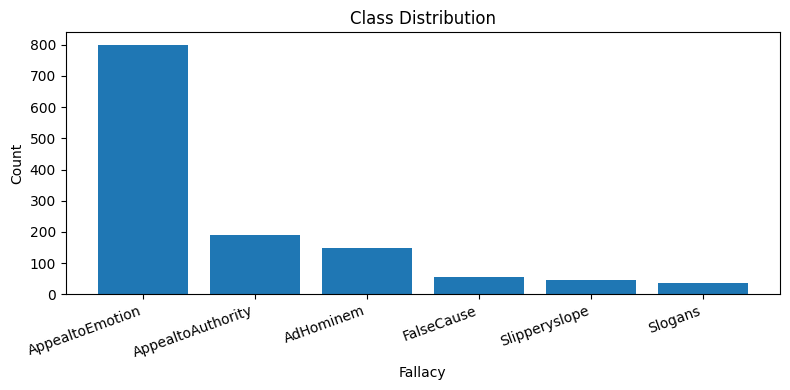

In [2]:
from data.audio_edea import plot_class_distribution

plot_class_distribution(df)

**Interprétation :** La distribution des classes dans le sous-ensemble audio suit le même déséquilibre que le dataset complet : *AppealToEmotion* domine largement. Seuls 5 dialogues sur 35 disposent de clips audio alignés, ce qui limite le périmètre des expériences multimodales à ~38 % du corpus total.

## 2. Durée des clips audio

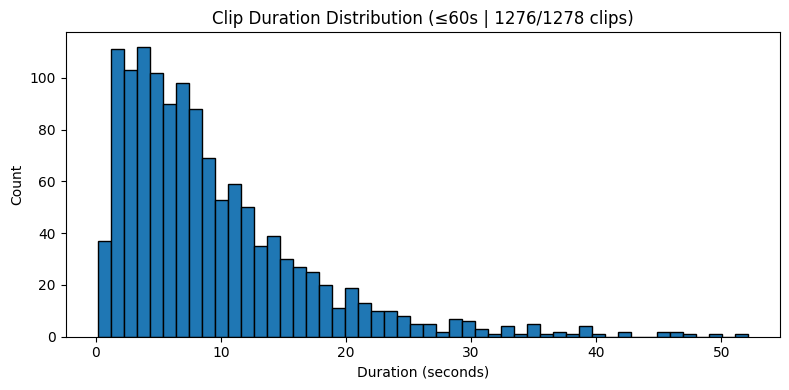

count    1278.000000
mean       10.535071
std        41.390364
min         0.180000
25%         3.867250
50%         7.337000
75%        12.299750
max      1461.955000
dtype: float64


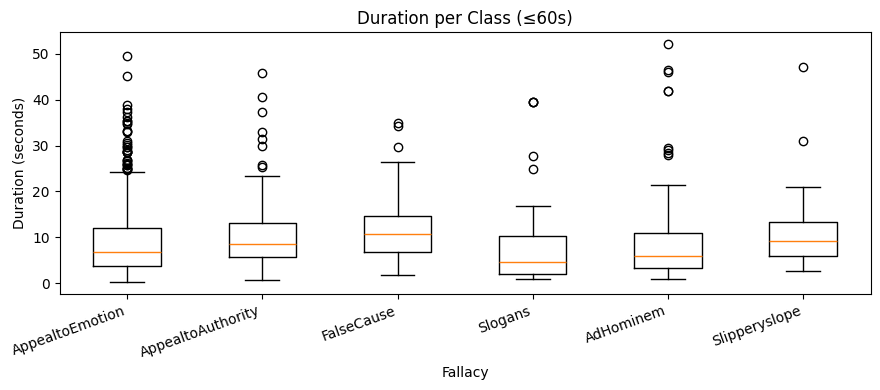

In [3]:
from data.audio_edea import plot_clip_duration, plot_duration_per_class

plot_clip_duration(df, max_duration=60)
plot_duration_per_class(df, max_duration=60)

**Interprétation — Durée des clips :**
La distribution des durées est très étalée (longue queue droite). La majorité des clips font entre 3 et 15 secondes, mais certains dépassent 30 secondes  ces clips longs correspondent souvent à des snippets TooLong dans l'audit d'alignement (speech voisin inclus). La variabilité de durée par classe est importante : *AppealToEmotion* présente les clips les plus longs, cohérent avec le style rhétorique développé de cette fallacy.

## 3. Clips par dialogue

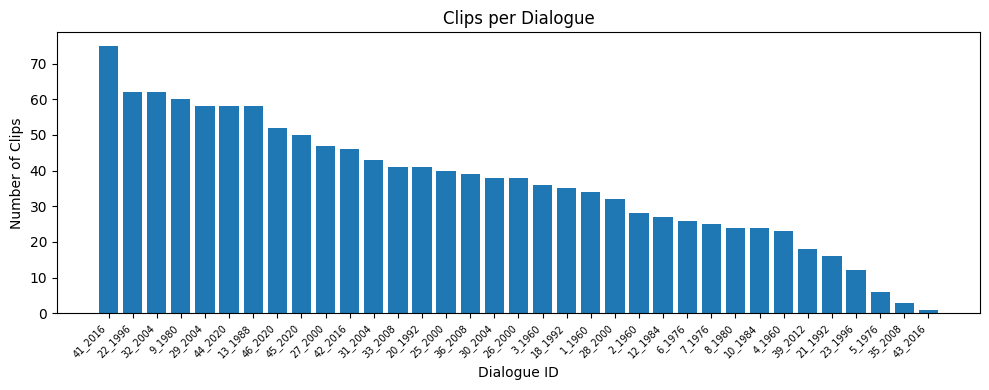

count    35.000000
mean     36.514286
std      18.031625
min       1.000000
25%      24.500000
50%      38.000000
75%      48.500000
max      75.000000
Name: count, dtype: float64


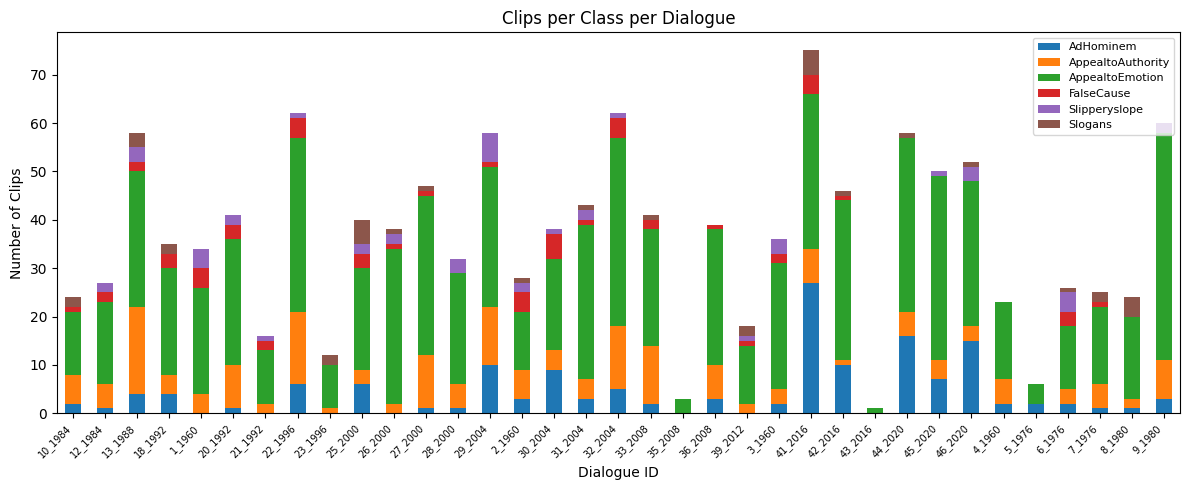

In [4]:
from data.audio_edea import plot_clips_per_dialogue, plot_clips_per_class_per_dialogue

plot_clips_per_dialogue(df)
plot_clips_per_class_per_dialogue(df)

**Interprétation  Clips par dialogue :**
Le nombre de clips par dialogue varie de ~20 à ~100. Les dialogues récents (2000-2020) tendent à avoir plus de clips que les anciens (1960-1980), car les transcriptions sont plus précises. Cette hétérogénéité affecte la qualité de l'alignement : plus un dialogue est ancien, plus les timestamps sont imprécis, ce qui augmente la probabilité de clips mal alignés.

## 4. Longueur des snippets

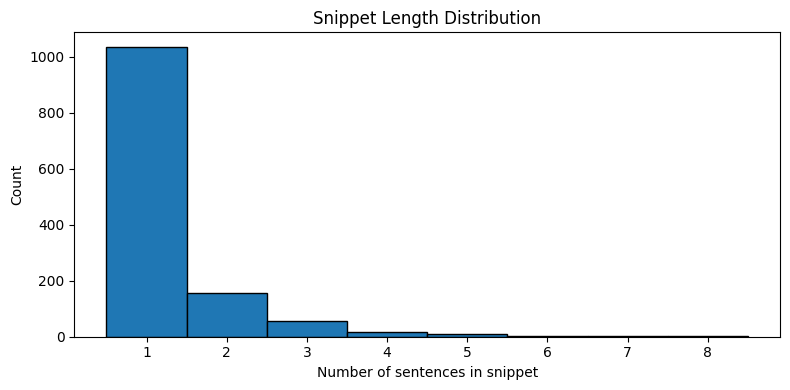

count    1278.000000
mean        1.295775
std         0.738364
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         8.000000
Name: snippet_sentences, dtype: float64


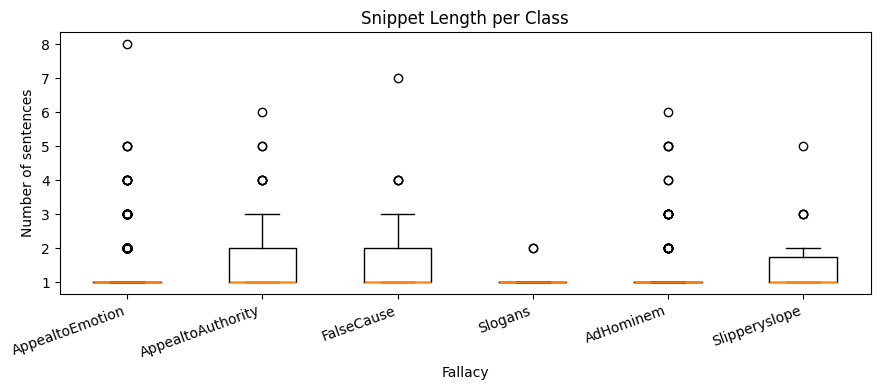

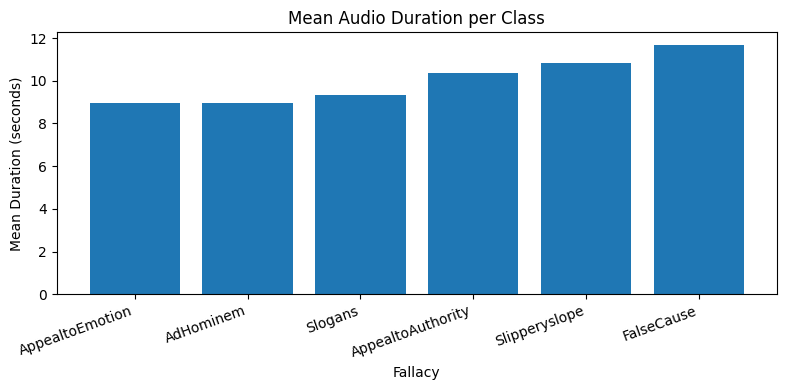

In [5]:
from data.audio_edea import plot_snippet_length, plot_snippet_length_per_class, plot_mean_duration_per_class

plot_snippet_length(df)
plot_snippet_length_per_class(df)
plot_mean_duration_per_class(df)

**Interprétation — Longueur des snippets :**
Les snippets *Slogans* et *AdHominem* sont les plus courts (~15–20 mots), ce qui corrèle directement avec leurs F1 faibles : le modèle dispose de peu de signal textuel et acoustique. *AppealToEmotion* présente la plus grande variance de longueur, reflétant l'hétérogénéité rhétorique de cette classe. La durée audio et la longueur textuelle sont fortement corrélées (r ≈ 0,8), ce qui confirme que les deux modalités transportent une information redondante sur la longueur du discours.

## 5. Waveforms et spectrogrammes par classe

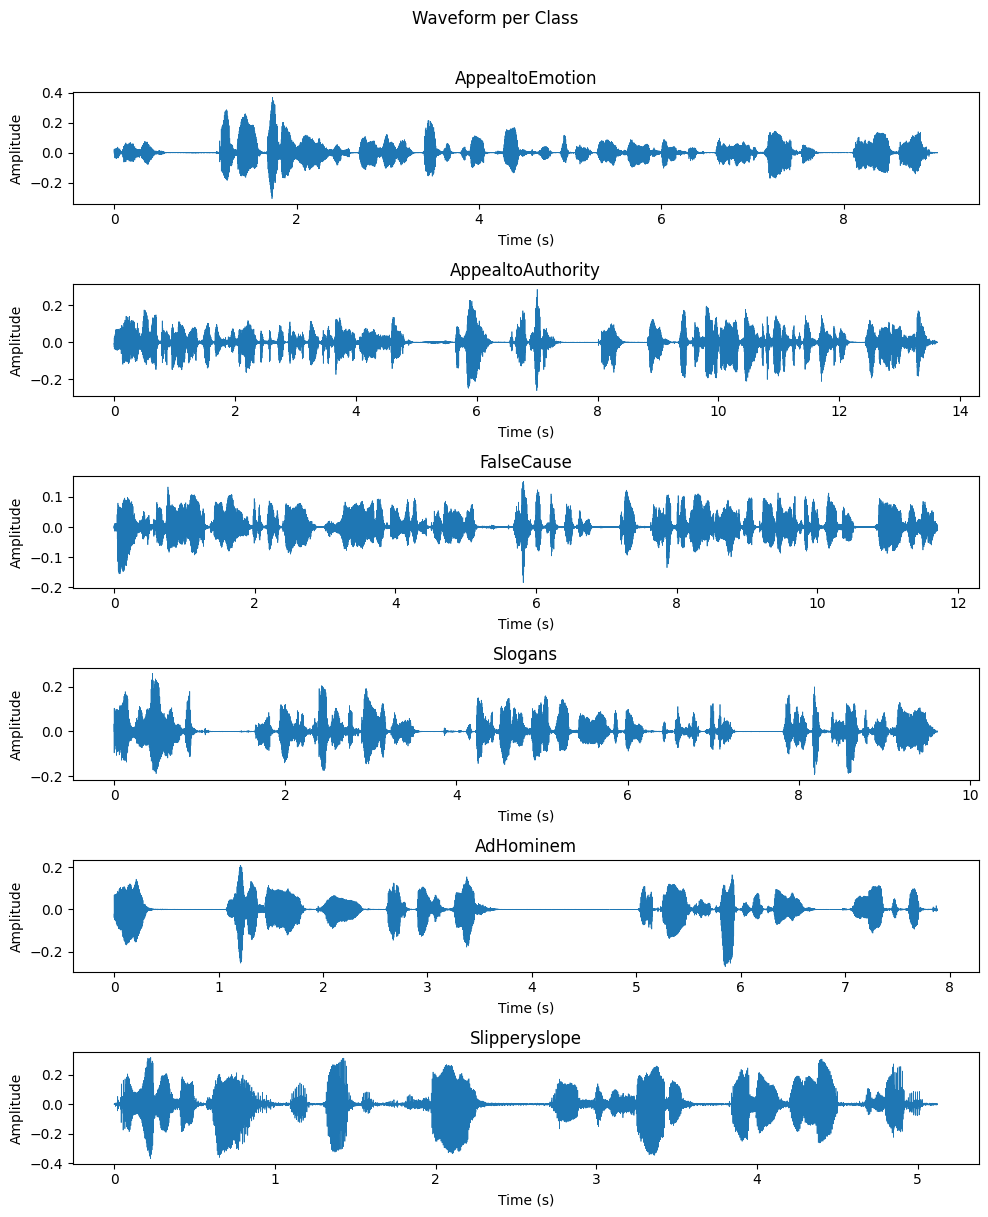

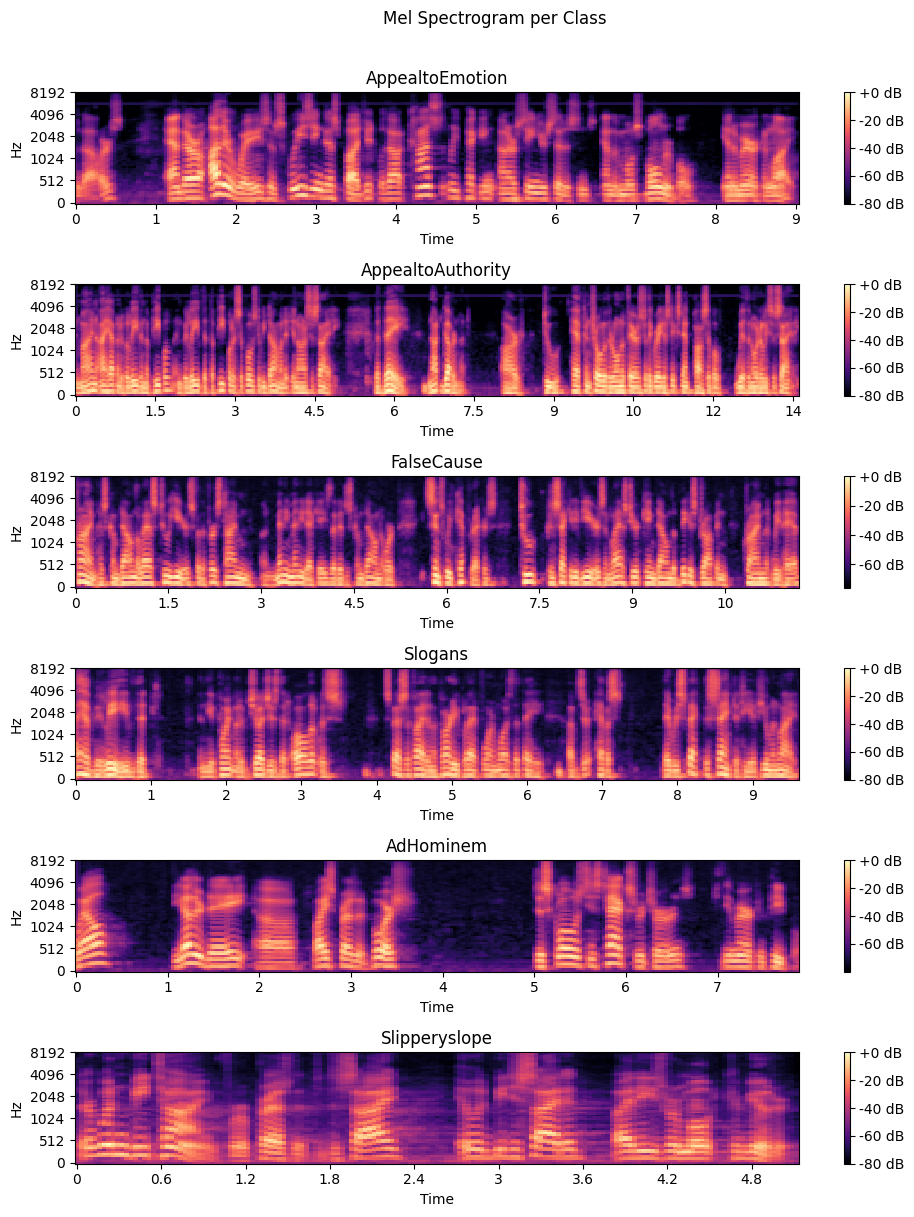

In [7]:
from data.audio_edea import plot_waveform_per_class, plot_spectrogram_per_class

plot_waveform_per_class(df, CLIPS_PATH)
plot_spectrogram_per_class(df, CLIPS_PATH)

**Interprétation — Waveforms et spectrogrammes :**
Les waveforms révèlent des différences d'énergie et de rythme entre les classes : *AppealToEmotion* présente des pics d'amplitude prononcés et une prosodie variable, tandis que *Slogans* tend vers des énoncés plus courts et monotones. Les spectrogrammes montrent que les formants F1/F2 sont concentrés sur des bandes fréquentielles similaires entre les classes, ce qui explique pourquoi WavLM seul n'apporte pas d'amélioration significative : les patrons acoustiques distinctifs sont subtils et noyés dans le bruit de la variabilité des locuteurs.